# Notebook 02 — Sentiment Analysis via NLP
# Project: Ad Engagement Analysis
# Goal: Compute Comment Polarity from user textual data

In [1]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

try:
    df = pd.read_csv('../data/comments_cleaned.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    import sys
    print("Dataset not found. Please ensure 'comments_cleaned.csv' is in 'data' folder.")
    sys.exit(1)

display(df[['comment']].head())

Dataset loaded successfully.


,comment
0,fantastic. wonderful experience.
1,broke easily. awful.
2,met expectations. five stars.
3,very satisfied. wonderful experience.
4,worst purchase. one star.


## 1. Natural Language Processing Pipeline
TextBlob extracts polarity of comments. Polarity is a continuous float representing sentiment (-1 to +1).

In [2]:
df['comment'] = df['comment'].astype(str)

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment_score'] = df['comment'].apply(get_sentiment)

def categorize_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)
print("Sentiment Categorization complete.")
print(df[['comment', 'sentiment_score', 'sentiment_category']].head(10))

Sentiment Categorization complete.
                                             comment  sentiment_score  \
0                   fantastic. wonderful experience.         0.700000   
1                               broke easily. awful.        -1.000000   
2                      met expectations. five stars.         0.000000   
3              very satisfied. wonderful experience.         0.825000   
4                          worst purchase. one star.        -1.000000   
5               some pros and cons. works perfectly.         1.000000   
6                highly recommend. amazing features.         0.380000   
7                      waste of money. poor quality.        -0.300000   
8  love this product. highly recommend. nothing s...         0.339048   
9                      poor quality. worst purchase.        -0.700000   

  sentiment_category  
0           Positive  
1           Negative  
2            Neutral  
3           Positive  
4           Negative  
5           Positive  


## 2. Visualize Sentiment Across Ads

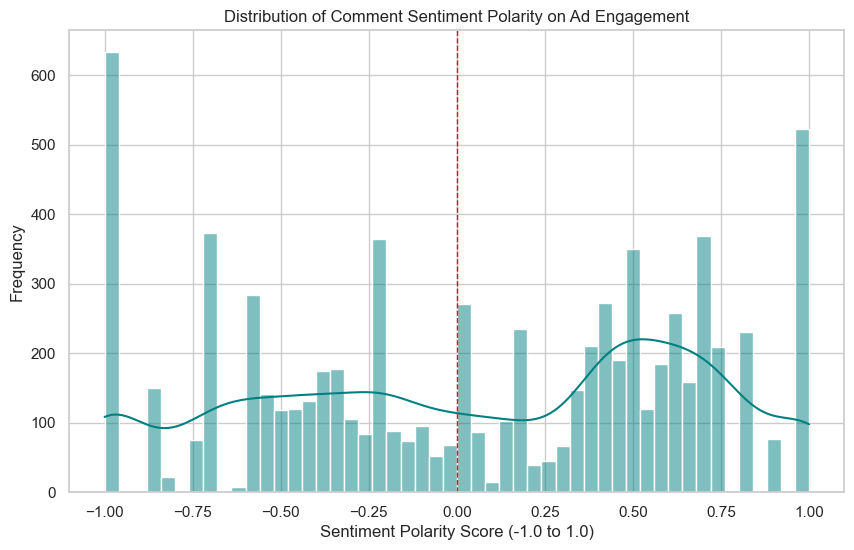

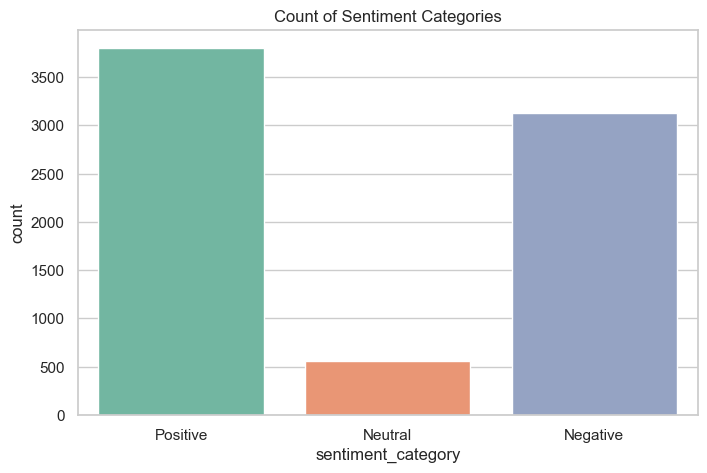

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_score'], bins=50, kde=True, color='teal')
plt.title('Distribution of Comment Sentiment Polarity on Ad Engagement')
plt.xlabel('Sentiment Polarity Score (-1.0 to 1.0)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment_category', data=df, palette='Set2', order=['Positive', 'Neutral', 'Negative'])
plt.title('Count of Sentiment Categories')
plt.show()